In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("Libraries installed successfully")

Libraries installed successfully


In [ ]:
import zipfile
import os

# Extract bank.zip
with zipfile.ZipFile('/content/bank.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/bank_data')

# Extract bank-additional.zip
with zipfile.ZipFile('/content/bank-additional.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/bank_additional_data')

print("Datasets extracted successfully")

Datasets extracted successfully


In [ ]:
import os

print(os.listdir('/content/bank_data'))
print(os.listdir('/content/bank_additional_data'))

['bank-names.txt', 'bank.csv', 'bank-full.csv']
['bank-additional', '__MACOSX']


In [ ]:
# Load dataset

file_path = '/content/bank_data/bank-full.csv'

df = pd.read_csv(file_path, sep=';')

# Display first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Dataset shape and information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape:
(45211, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null

In [ ]:
# Check missing values

print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


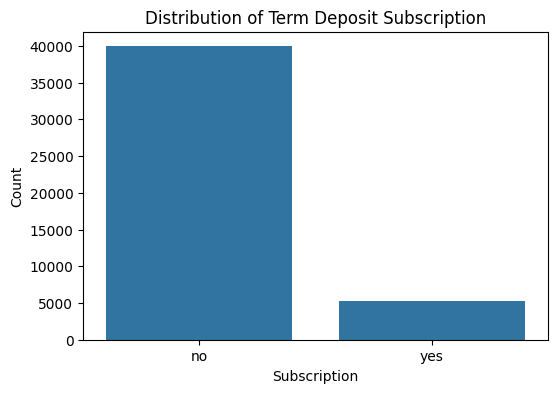

In [ ]:
# Target variable distribution

plt.figure(figsize=(6,4))

sns.countplot(x='y', data=df)

plt.title('Distribution of Term Deposit Subscription')

plt.xlabel('Subscription')

plt.ylabel('Count')

plt.show()

In [ ]:
# Encode categorical columns

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Convert all object columns into numeric
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

print("Categorical variables encoded successfully")

df.head()

Categorical variables encoded successfully


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


In [ ]:
# Define features and target

X = df.drop('y', axis=1)

y = df['y']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (45211, 16)
Target Shape: (45211,)


In [ ]:
# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (36168, 16)
Testing Data Shape: (9043, 16)


In [12]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:")
print(accuracy_log)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy:
0.8882008183125069

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.60      0.23      0.33      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


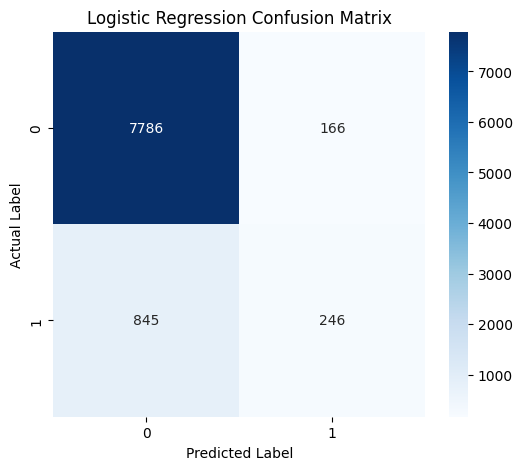

In [13]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.show()

In [14]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:")
print(accuracy_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:
0.8740462235983634

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.48      0.48      0.48      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.87      0.87      0.87      9043



In [15]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:")
print(accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.9004755059161783

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [16]:
# KNN Model

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:")
print(accuracy_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy:
0.8762578790224483

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      7952
           1       0.48      0.28      0.35      1091

    accuracy                           0.88      9043
   macro avg       0.69      0.62      0.64      9043
weighted avg       0.85      0.88      0.86      9043



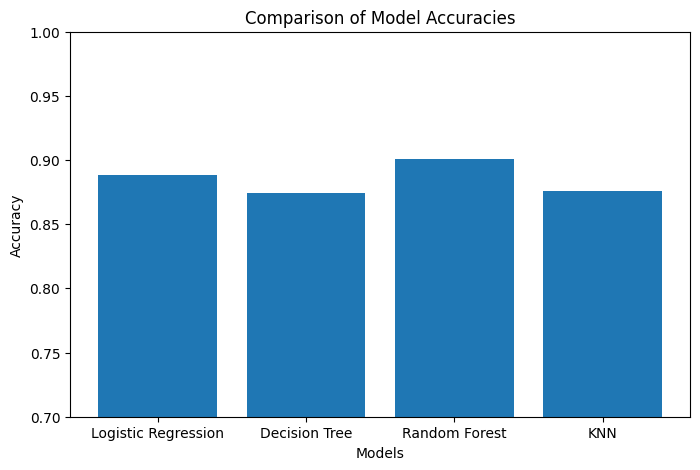

In [17]:
# Compare model accuracies

models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest',
          'KNN']

accuracies = [accuracy_log,
              accuracy_dt,
              accuracy_rf,
              accuracy_knn]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Comparison of Model Accuracies')

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.ylim(0.7, 1.0)

plt.show()

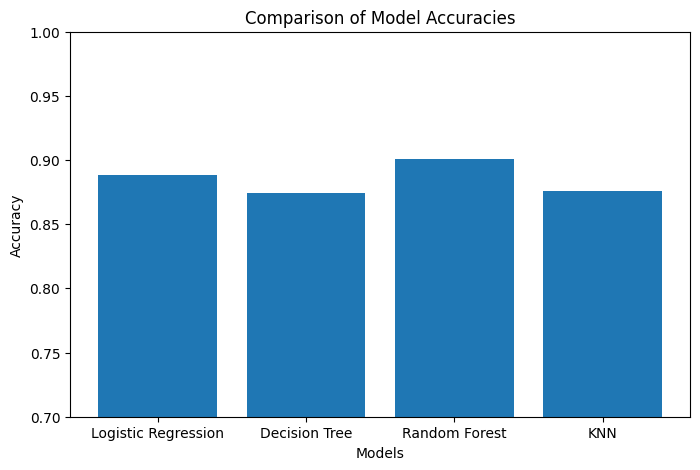

PDF figure saved successfully


In [18]:
# Save graph as PDF

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Comparison of Model Accuracies')

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.ylim(0.7, 1.0)

plt.savefig('model_accuracy_comparison.pdf',
            format='pdf',
            bbox_inches='tight')

plt.show()

print("PDF figure saved successfully")

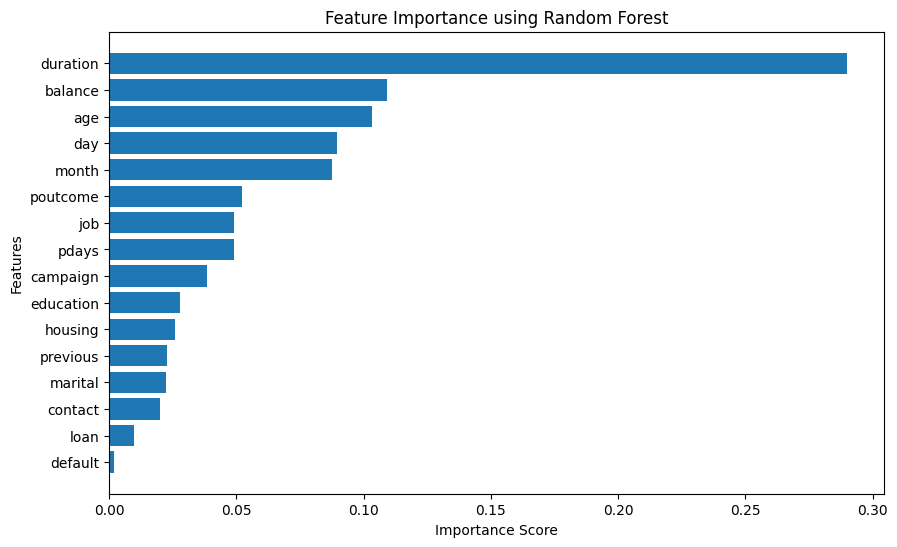

In [19]:
# Feature Importance using Random Forest

feature_importance = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort values
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot graph
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.title('Feature Importance using Random Forest')

plt.gca().invert_yaxis()

plt.show()

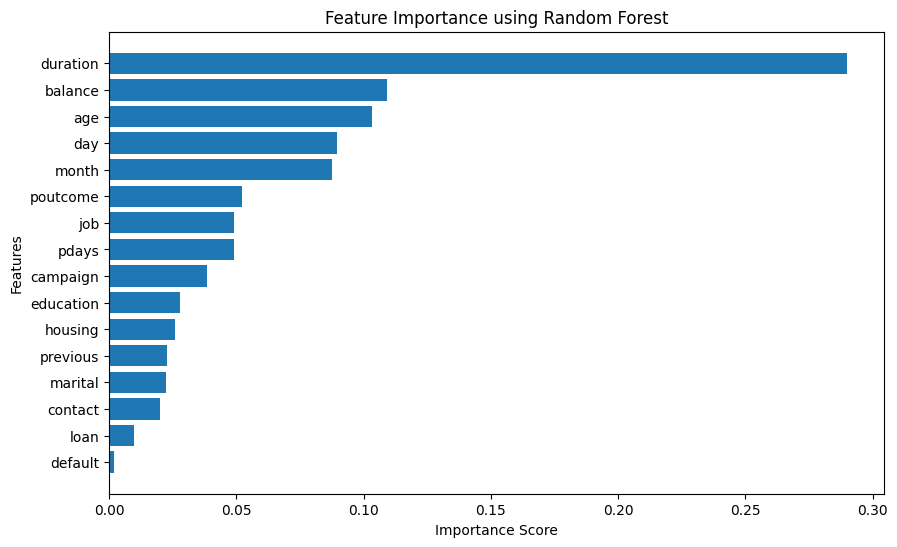

Feature Importance PDF saved successfully


In [20]:
# Save Feature Importance Graph as PDF

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.title('Feature Importance using Random Forest')

plt.gca().invert_yaxis()

plt.savefig(
    'feature_importance.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

print("Feature Importance PDF saved successfully")

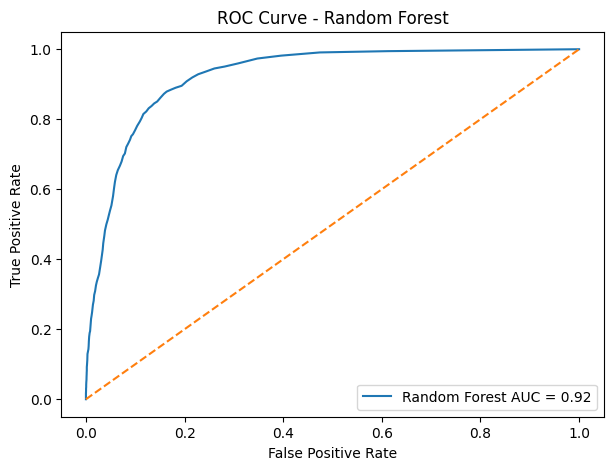

In [21]:
# ROC Curve for Random Forest

from sklearn.metrics import roc_curve, auc

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr,
         label='Random Forest AUC = %0.2f' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Random Forest')

plt.legend(loc='lower right')

plt.show()

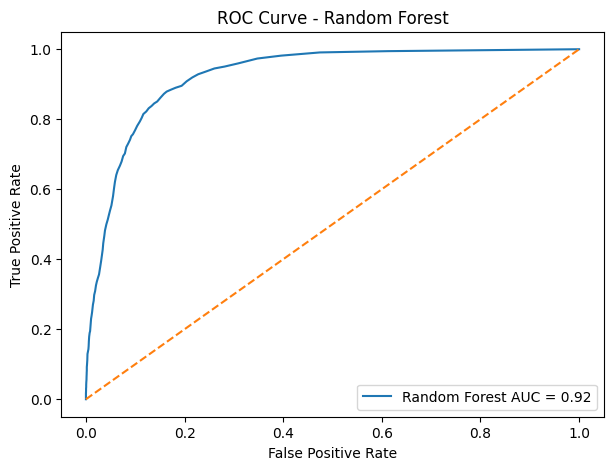

ROC Curve PDF saved successfully


In [22]:
# Save ROC Curve as PDF

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr,
         label='Random Forest AUC = %0.2f' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Random Forest')

plt.legend(loc='lower right')

plt.savefig(
    'roc_curve_random_forest.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

print("ROC Curve PDF saved successfully")

In [23]:
# Create Results Table

results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        accuracy_log,
        accuracy_dt,
        accuracy_rf,
        accuracy_knn
    ]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.888201
1,Decision Tree,0.874046
2,Random Forest,0.900476
3,KNN,0.876258


In [24]:
# Save results table

results_df.to_csv(
    'model_results.csv',
    index=False
)

print("Results table saved successfully")

Results table saved successfully


In [25]:
plt.savefig("logistic_confusion_matrix.pdf", format="pdf", bbox_inches="tight")
print("Confusion matrix saved successfully")

Confusion matrix saved successfully


<Figure size 640x480 with 0 Axes>